<a href="https://colab.research.google.com/github/Froststar16/canopy-watch-hyderabad/blob/main/notebooks/01_setup_ndvi_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canopy Watch — Hyderabad
### Phase 1: Setup + NDVI time series MVP

This notebook:
1. Installs and authenticates Google Earth Engine
2. Mounts Google Drive for persistent output storage
3. Defines a placeholder area of interest (AOI) for Hyderabad/GHMC
4. Pulls a yearly mean NDVI (vegetation index) time series from Sentinel-2, 2016–present
5. Saves results as CSV + a trend chart

Replace the placeholder AOI in Section 3 with a real GHMC boundary once you've sourced one (see README, Phase 2).

## 1. Install dependencies

In [ ]:
!pip install earthengine-api geemap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.2 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import os

## 2. Authenticate Earth Engine + mount Drive

`ee.Authenticate()` will open a browser auth flow the first time you run this.
Replace `PROJECT_ID` below with the Cloud project ID you got when registering at https://signup.earthengine.google.com

If your school Google account has restricted Cloud project creation, register for Earth Engine with a personal Gmail instead — you can still mount your school Drive separately below, they're independent auth flows.

In [ ]:
ee.Authenticate()
ee.Initialize(project='canopy-watch-hyderabad')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Outputs will be saved to:', OUTPUT_DIR)

Mounted at /content/drive
Outputs will be saved to: /content/drive/MyDrive/canopy-watch-hyderabad/outputs


## 3. Define area of interest (AOI)

**Placeholder for now**: a rough bounding box around Hyderabad/GHMC.
Replace this with an actual GHMC or ward-level boundary once sourced (Telangana State GIS portal, OpenStreetMap via Overpass Turbo, or Data{Meet}/OpenCity India shapefiles) — this is what will let you localize hotspots by neighborhood in Phase 2.

In [ ]:
# Rough Hyderabad/GHMC bounding box — REPLACE with real boundary geometry when available
hyderabad_aoi = ee.Geometry.Rectangle([78.30, 17.20, 78.65, 17.55])

# Quick visual sanity check
m = geemap.Map(center=[17.38, 78.48], zoom=10)
m.addLayer(hyderabad_aoi, {'color': 'red'}, 'AOI (placeholder)')
m

Map(center=[17.38, 78.48], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 4. NDVI pipeline

NDVI (Normalized Difference Vegetation Index) is computed from Sentinel-2's near-infrared (B8) and red (B4) bands. Higher NDVI = denser/healthier vegetation. We filter for low cloud cover, then take a yearly mean composite to smooth out seasonal/monsoon noise.

In [ ]:
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

def get_ndvi_collection(aoi, start_date, end_date, cloud_thresh=20):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(add_ndvi)
    )

In [ ]:
# Sentinel-2's usable archive starts ~2016 for full-year coverage
years = list(range(2016, 2027))
records = []

for year in years:
    start, end = f'{year}-01-01', f'{year}-12-31'
    coll = get_ndvi_collection(hyderabad_aoi, start, end)
    ndvi_mean_image = coll.select('NDVI').mean()
    stat = ndvi_mean_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=hyderabad_aoi,
        scale=10,
        maxPixels=1e9
    )
    ndvi_value = stat.get('NDVI').getInfo()
    records.append({'year': year, 'mean_ndvi': ndvi_value})
    print(year, ndvi_value)

df = pd.DataFrame(records)
df.to_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_yearly.csv', index=False)
df

2016 0.25997036033583865
2017 0.29506345587135147
2018 0.28472355823871187
2019 0.250432060558911
2020 0.2879425132793559
2021 0.27726580161828723
2022 0.285669953056555
2023 0.29749494171533303
2024 0.2590270683313424
2025 0.29419481929984903
2026 0.26554080840677585


,year,mean_ndvi
0,2016,0.259970
1,2017,0.295063
2,2018,0.284724
3,2019,0.250432
4,2020,0.287943
5,2021,0.277266
6,2022,0.285670
7,2023,0.297495
8,2024,0.259027
9,2025,0.294195


## 5. Plot the trend

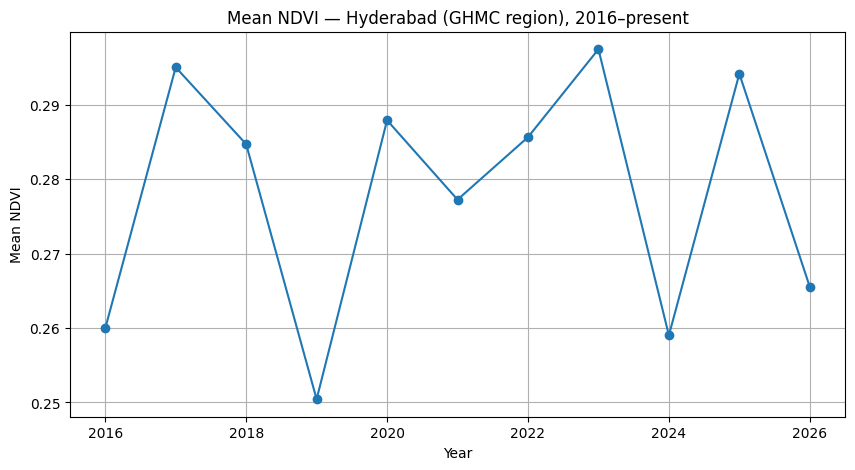

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['mean_ndvi'], marker='o')
plt.title('Mean NDVI — Hyderabad (GHMC region), 2016–present')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.grid(True)
plt.savefig(f'{OUTPUT_DIR}/ndvi_trend.png', dpi=150)
plt.show()

## Next steps

- Swap the placeholder AOI for a real GHMC/ward boundary → rerun this notebook per ward to localize hotspots.
- Move to a new notebook for Phase 3: pull Landsat thermal band, compute LST, correlate against this NDVI trend.
- Once both are working, source public Haritha Haram sapling-count data and compare against what the satellite actually shows.